In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

module_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import functions
import plot_config as pc

pc.apply_custom_mpl_settings()

<h1><span style="color:orange">Numerical Simulation Laboratory(NSL)</span></h1>

<h2><span style="color:green">Numerical exercises 3</span></h2>

This notebook aims to **compare the prices of European call and put options** obtained by simulating the time evolution of the asset price (modeled by a Geometric Brownian Motion) in two different ways:

1. directly sampling the final asset price;
2. discretizing its time evolution;

The results will be compared with the values predicted by the Black-Scholes-Merton (**BSM**) analytical formula.



<h3><span style="color:darkviolet">Stochastic calculus</span></h3>

To describe the time evolution of stocastic processes (whether discrete or continuous in time) it is necessary to define a type of equations, as we do for traditional deterministic processes. These are call **Stochastic Differential Equations** (**SDEs**) and their solutions can be thought as probability distributions of trajectories. Traditional differential calculus or variational calculus techniques can not be directly applied to these phenomena, making it necessary to introduce a generalization of differential equations.




<h4><span style="color:darkviolet">Time continuous stocastic processes</span></h4>

The first rigorous mathematical theory describing *Brownian motion* (the seemingly random motion of small particles suspended in a fluid, caused by collisions with the surrounding fluid molecules) was produced by N. Wiener in 1923.

We define a **Wiener Process** (or **Standard Brownian Motion**) as a time-continuous stochastic process $\{W(t),~ t \ge 0 \}$ with the following properties:

1. $W(0)=0$;

2. the increments $W(t)-W(s)$ are **stationary** and **indipendent** (the probability associated to the increment depends only on the time difference $t-s$);

3. for $t>s$, $W(t)-W(s)$ has a Normal distribution $N(0;t-s)$ (mean value equal to zero and variance equal to $t-s$):

4. it is **self-similar** ($W(at) \stackrel{\text{stat}}{=} a^{1/2}W(t),$ where $\stackrel{\text{stat}}{=}$ means statistically equal) exhibiting fractal property.

Condition $2$ and $3$ imply that a Wiener process $W(t)$ is distributed as $N(0;t)$, and therefore it describes a **diffusion process** (since the variance is a linear function of time). We can sample a Wiener process without any discretization error using the following formula:

$$W(t_{i+1}) = W(t_{i}) + Z_{i+1}\sqrt{t_{i+1}-t_{i}},$$

where $Z_i = N(0,1)$ are i.i.d. Normal increments and $i = 0,~1,~...,~n$.

Wiener process paths have the following properties:

- they are continuous;

- they are nowhere differentiable (this property prevents the use of a standard differential definition).

<h5><span style="color:darkviolet">Mean-squared limit and stochastic integrals</span></h5>

Even though Wiener process paths are not differentiable is possible to define a differential introducing a new type of convergence, the so called **mean-square limit**, often denoted as $L^2$ **limit**:

$$\lim_{n \to \infty}^{\text{L2}} X_n = \text{ms-}\lim_{n\to\infty}X_n = X \iff \lim_{n \to \infty} \langle (X_n - X)^2 \rangle = \lim_{n \to \infty} \mathbb{E} \left[ (X_n - X)^2 \right] = 0.$$

This is a statistical convergence because it requires the Mean Squared Error (MSE), computed using PDF, tend to zero.

This convergence (weaker than the point-wise convergence) allow to define the differential of a Wiener process as mean-square limit of the Wiener process increment and similarly (analogous to the Riemann integral) the stocastic integral of a function $G(t)$ over an interval $(t_0,t_n)$ is defined as:

$$\int_{t_0}^{t_n}G(t')dW(t') \equiv \lim_{n \to \infty}^{\text{L2}} \sum_{i=1}^{n}G(\tau_{i})[W(t_i)-W(t_{i-1})]$$

In this context, a SDE can be viewed as a stochastic integral equation.

It is crutialto note that, unlikely the Riemann integral, the stochastic integral is not uniquely defined until we choose the point $\tau$ in which the integrand $G(\cdot)$ is evaluated within the interval $[t_{i-1}; t_i]$. The two most frequent choises are:

- **Itô integral**: choosing $\tau = t_{i-1}$ (the left endpoint of the sub-interval);

- **Stratonovich integral**: choosing $\tau = \frac{t_i + t_{i-1}}{2}$ (the mid-point of the sub-interval).


We will focus on the **Itô integrals** beacuse its resulting stochastic integral has the important property of being a **martingale** (meaning the best estimator for the next value, given all past information, is the actual value) which is a main feature often attributed to financial markets.

The Itô integral has statistical equalities (often called **Itô rules**) that are essential for defining a Taylor expansion of stocastic processes (**Itô's Lemma**):

1. $[dW(t)]^2 \stackrel{\text{stat}}{=} dt$;

2. $[dW(t)]^{m} \stackrel{\text{stat}}{=} 0 ~~~ \forall ~ m \ge 3$;

3. $dt\cdot dW(t) \stackrel{\text{stat}}{=} 0$.

Using these relations we can compute the total differential of a functional $f\left[W(t), t\right]$ of a Wiener process using Taylor expansion (up to the first order in time):

$$df\left[W(t), t\right] = \left[\frac{\partial f\left[W(t), t\right]}{\partial t} + \frac{1}{2}\frac{\partial^2 f\left[W(t), t\right]}{\partial W^2}\right]dt + \frac{\partial f\left[W(t), t\right]}{\partial W}dW(t).$$

<h5><span style="color:darkviolet">Stochastic Differential Equations</span></h5>

It is now possible to define an **Itô stochastic differential equation**.

A stochastic process $X(t)$ is said to obey an **Itô SDE**, written in differential form as:

$$dX(t) = a\left[X(t),t\right]dt + b\left[X(t),t\right]dW(t)$$

when $\forall$ $t_0$, $t$ we have:

$$X(t) = X(t_0) + \int_{t_0}^{t}dt'~a\left[X(t'),t'\right] + \int_{t_0}^{t}dW(t')~b\left[X(t'),t'\right].$$

$a\left[X(t'),t'\right]$ is named **drift coefficient** and $b\left[X(t'),t'\right]$ **diffusion coefficient**, 

Supposing a stochastic process $X(t)$ which fulfills the SDE defined above, if we consider a functional of the stochastic process and time ($f\left[X(t),t\right]$) we can compute its differential. By applying Itô rules to the Taylor series expansion, we obtain the **Itô formula**, which describes the total differential of a functional of a generic Itô stochastic process:

$$df\left[X(t),t\right] = \left\{\frac{\partial f\left[X(t),t\right]}{\partial t} +a\left[X(t),t\right]\frac{\partial f\left[X(t),t\right]}{\partial X} + \frac{1}{2}b^2\left[X(t),t\right]\frac{\partial^2 f\left[X(t),t\right]}{\partial X^2}\right\}dt + b\left[X(t),t\right]\frac{\partial f\left[X(t),t\right]}{\partial X}dW(t).$$

<h5><span style="color:darkviolet">Not Standard Brownian Motion</span></h5>

We define a **Generic Brownian Motion** a stochastic process $X(t) \sim \mathrm{BM}(\mu, \sigma^2)$ with **drift** $\mu$ and **diffusion coefficient** $\sigma$ if:

$$\frac{X(t)- t\mu}{\sigma} \sim \mathrm{BM}(0,1)$$

where $\mathrm{BM}(0,1)$ is a Wiener Process (Standard Brownian Motion).

The definition above implies several properties:

1. a **not Standard Brownian Motion** is a functional of a Wiener process and its evolution is governed by the Itô SDE (using Itô formula):

    $$X(t) = \mu t + \sigma W(t) \implies dX(t) = \mu dt + \sigma dW(t).$$

1. Since a Wiener Process $W(t)$ is distributed as $N(0,t)$ and it's self-similar, **a not Standard Brownian Motion** $X(t)$ **is distributed as** $N(\mu t, \sigma^2 t)$.

3. Its path can be sampled exavtly (without any discretization error, meaning the joint distribution of simulated values coincides with the joint distribution of the Brownian motion) using the increment formula of the Wiener Process path sampling:

    $$X(t_{i+1})=X(t_i)+\mu(t_{i+1}−t_i)+\sigma Z_{i+1} \sqrt{t_{i+1}−t_i}.$$

Not Standard Brownian Motion is so important because it was first used by Chevalier in 1900 as a mathematical model to describe financial market dynamics. Howeve, it posses a critical drawback for modeling asset prices: its values can be both positive or negative. Since asset price can not bbe negative, this model is unsuitable. There is a different type of Brownian Motion (the **Geometric Brownian motion**, introduced by Itô in 1944) which can be used as a simple model to describe the financial market dynamics.

<h5><span style="color:darkviolet"> Geometric Brownian motion as financial market model</span></h5>

An asset (product of the financial market) is characterized by a price, the **spot price** $S(t)$, that evolves in time. This evolution is modeled as a combination of a deterministic component (analogous to a bank deposit described by a **risk-free interest rate**, $\mu$) and stochastic fluctuations, quantified by **volatility** $\sigma$.

**Deterministic evolution**:

If the interest is compounded continuously over time, the asset price follows the well-known exponential growth formula. Starting from the discrete compounding formula with n payments:

$$S(t) = S(0) \left( 1 + \frac{\mu t}{n} \right) ^n.$$

In the limit of continuous compounding ($n \to \infty$), the price becomes:

$$S(t) = S(0) \cdot e^{\mu t}.$$

A reasonable ansatz for describing the deterministic evolution of the asset price's infinitesimal change $dS(t)$ is:

$$dS(t) = \mu S(t) dt.$$

**Stochastic evolution**:

The stochastic nature of the price evolution must also be included. According to the efficient market hypothesis, the price process is typically assumed to be **Markovian**. A symmetric ansatz for the stochastic part is chosen as:

$$dS(t) = \sigma S(t) dW(t).$$

Combinig these two components, we obtain the **SDE** which defines the **Geometric Brownian Motion (GBM)**:

$$dS(t) = \mu S(t) dt + \sigma S(t) dW(t).$$

This is a specific case of an Itô process where both the **drift** $a$ and the **volatility** $b$ coefficients are proportional to the spot price:

- $a\left[S(t),t\right] = \mu S(t)$;

- $b\left[S(t),t\right] = \sigma S(t)$.

This form suggests that the relevant quantity to model using a Not Standard Brownian Motion is not the spot price $S(t)$ itself but the **return** $\frac{dS(t)}{S(t)}$, which also is financially consistent. Dividing the SDE by $S(t)$ we obtain the differential of the natural logarithm of the price $\mathrm{ln}(S(t))$. Applying the **Itô formula** to $f(S(t)) = \mathrm{ln}(S(t))$ we correctly account for the stochastic nature of $dW(t)$:

$$d\mathrm{ln}(S(t)) = \left( \mu - \frac{1}{2} \sigma^2 \right)dt + \sigma dW(t).$$

Thus we conclude that the **logarithm of the spot price**, and not the price itself, performs a Not Standard Brownian Motion, characterized by a **reduced drift** $\mu^* = \mu - \sigma^2 / 2$ and **volatility** $\sigma$.

Previous discussion implies that $d\mathrm{ln}(S(t))$ is normally distributed with:

- mean given by $\left( \mu - \frac{1}{2} \sigma^2 \right)dt$;

- variance given by $\sigma^2 dt$.

The transition probability from $S(t)$ to $S(t')$ is distributed as a **log-normal distribution**:

$$p(S(t') \mid S(t)) = \frac{1}{\sqrt{2 \pi (\sigma S')^2 (t'-t)}} \cdot \mathrm{exp} \left(\frac{\mathrm{ln}\left(\frac{S'}{S}\right)- \left( \mu - \frac{\sigma^2}{2}\right) \cdot (t'- t)^2}{2 \pi \sigma^2 (t'-t)} \right)$$

and its evolution is the exponentiation of a Not Standard Brownian Motion:

$$S(t) = S(0) \cdot \mathrm{exp}\left[\left(\mu - \frac{1}{2} \sigma^2\right)t + \sigma W(t)\right].$$

Moreover we can get the exact sampling algorithm by exponentiating the sampling algorithm of a Generic Brownian Motion:

$$S(t_{i+1}) = S(t_i) \cdot \mathrm{exp}\left[\left(\mu - \frac{1}{2} \sigma^2\right)(t_{i+1}-t_i) + \sigma Z_{i+1} \sqrt{t_{i+1}-t_i}\right],$$

where $Z_{i+1}$ is a standard normally distibuted stochastic variable.

It is crucial to state that real financial markets often **deviate significantly** from the assumptions inherent in the GBM model:

1.  **Non-Gaussian Returns (Heavy Tails):** Real-world asset returns frequently exhibit **fat tails**, meaning extreme market movements occur **more often** than the log-normal model predicts (their probability distributions decay much slower than the Gaussian (or normal) distribution assumed by the log-normal model).
2.  **Non-Constant Parameters:** The GBM assumes **constant** drift ($\mu$) and volatility ($\sigma$). Empirically, both are often **time-dependent** or **stochastic** (e.g., exhibiting volatility clustering).
3.  **Path Dependence and Long-Range Correlation:**  The GBM model, based on the Wiener Process, assumes that price movements are Markovian **Markovian** (memoryless). However, empirical evidence suggests that returns time series can exhibit **long-range dependence** with past price history, violating the Markov property.

<h5><span style="color:darkviolet"> European Options</span></h5>

**European options** are the simplest type of derivate contracts in the financial market. They represent an agreement between two parties in which the **writer** (the seller of the option) grants the **holder** (the buyer of the option) the right, but not the obligation, to purchase (**call option**) from him or to sell (**put option**) to him an underlying asset for a prescripted price $K$ (**strike price**) at the **expiry date** $T$ in the future. The holder will exploit his right only if he gains a profit :
- he will perform a **call option** only if $K \le S(t)$ so that he can buy an asset at a lower price from the writer and sell to the market at an higer price, so 

    $$\text{profit} = \mathrm{max}(0, S(t)-K);$$

- he will perform a **put option** only if $K \ge S(t)$ so that he can buy an asset at a lower price from the market and sell to the writer at an higer price, so

    $$\text{profit} = \mathrm{max}(0, K-S(t)).$$

Since option are **one way contracts** (or unilateral contracts) the writer requires a compensation. This compensation is the **option price** (or **premium**) The fair price of the call option (C) and the put option (P) can be computed using pricing models, such as the Black-Scholes formula, or estimated via Monte Carlo simulations.

<h2><span style="color:darkviolet">European call and put options simulation</span></h2>

We want to compute at time $t = 0$ the European **call-option price**, $C[S(0),0]$, and **put-option price**, $P[S(0),0]$ via Monte Carlo simulations. The results will be compared against the analytical solutions provided by the **Black-Scholes-Merton (BSM)** model.

The simulation employs two distinct sampling methodologies for the asset price $S(t)$, which is modeled as a $\text{GBM}(\mu,\sigma^2)$ process:

1. **direct sampling** at the expiry timr of the final asset price $S(T)$;

2. **discretized sampling** of the path of the asset price dividing $[0,T]$ in $10^2$ time intervals: $S(0)$, $S(t_1)$, $S(t_2)$, ... up to $S(t_{100}=T=1)$.

<h4>Implementation</h4>

The Monte Carlo simulation relies on the following set of financial and control parameters:

| Parameter | Symbol | Value | Description |
| :--- | :--- | :--- | :--- |
| **Total Samples** | `M` | $10^6$ | Total number of GBM paths/samples simulated. |
| **Number of Blocks** | `N` | $100$ | Number of blocks used for **Data Blocking** analysis. |
| **Initial Spot Price** | `S0` | $100$ | Asset price at $t=0$. |
| **Expiry Time** | `T` | $1$ | End time of the contract. |
| **Strike Price** | `K` | $100$ | Option exercise price. |
| **Risk-Free Rate** | `drift` | $0.1$ | Constant instantaneous risk-free interest rate. |
| **Volatility** | `volatility` | $0.25$ | Constant instantaneous volatility. |
| **Time Steps** | `nstep` | $100$ | Number of steps for path discretization. |

The exact **sampling algorithm of a GBM** is implemented by the lambda function:
````cpp
    auto asset_evolution = [&] (double S0, double drift, double volatility, double t, double z){
        return S0 * exp((drift - 0.5 * volatility * volatility) * t + volatility * z * sqrt(t));
    };
````
Since the algorithm is exact, the function can be used to simulate in a discrete manner the GBM using time steps `time_steps` or the expiry date `T`.
One important thing to say is that:
- in discrete sampling the asset price has to be the one computed at the last step;
- in the direct sampling is the starting asset price at time t = 0.

**Call** and **put option prices** are computed by the two lambda functions:
````cpp
    auto call_prize = [] (double S, double K){
        return (S - K > 0 ? S - K : 0);
    };
````

and
````cpp
    auto put_prize = [] (double S, double K){
        return (K - S > 0 ? K - S : 0);
    };
````

The simulation employs a nested `for` loop structure to manage the Monte Carlo sampling and the statistical analysis:

1. **Inner Loop**: Iterates `L` times over the total number of sampling in each block.
    - This loop computes the final asset price $S(T)$. (For **discretized sampling**, this involves an additional inner-most loop over the `nstep` time steps of the GBM path).
    - The resulting call and put payoffs are calculated, and accumulated in the respective block variables, `acc_call` and `acc_put`.

2. **Outer Loop**: Iterates `N` times over the total number of blocks.
    - This loop discounts the option price to time `t=0` using the factor $e^{-rT}$, and computes the mean value for the block (`call_block_mean`, `put_block_mean`).
    - The progressive mean value over all blocks, along with the **progressive uncertainty** (computed using the external `error(mean_acc, mean2_acc, i)` function), is then determined.
    - All accumulated data are printed onto the output files.

<h2><span style="color:darkviolet">Black-Scholes-Merton analytic solution</span></h2>

Black-Scholes-Merton model relies on some assumptions:

1. Assumptions on Asset Price Dynamics:

    - **Geometric Brownian Motion (GBM)**: The instantaneous asset price is modeled as an Itô diffusion process following a GBM.

    - **Constant Volatility**: The instantaneous volatility parameter (σ) is assumed to be non-stochastic and constant throughout the option's life.

    - **Constant Risk-Free Rate**: The risk-free interest rate used for discounting and borrowing is assumed to be constant over time and is the same for all market participants.

2. Assumptions on Market Structure:

    - **Complete and Frictionless Market**: The market is assumed to be complete and frictionless. All trading is conducted without incurring any commissions or taxes.

    - **No Arbitrage**: The market is assumed to contain no risk-free arbitrage opportunities.

    - **European Exercise**: The derivative being priced must be a European option, meaning the right to exercise is available only at the expiry date $T$. 

Under these assuption Black, Scholes and Merton produced an analytic solution for European-style option prices at any time $t < T$. This groundbreaking theory led to the Nobel Prize in Economics (awarded to Scholes and Merton) in 1997.

The price of a European call option ($C$) and a European put option ($P$) at time $t$ are given by:

**CALL OPTION**: $C \left[ S(t), t \right] = S(t) \cdot N(d_1) - K \cdot \mathrm{exp}\left(- \mu\left(T - t\right)\right) \cdot N(d_2);$

**PUT OPTION**: $P \left[ S(t), t \right] = S(t) \cdot \left[ N(d_1) - 1 \right] - K \cdot \mathrm{exp}\left(- \mu\left(T - t\right)\right) \cdot \left[ N(d_2) - 1 \right],$

where:

- $S(t)$ is the spot price of the underlying asset at time $t$;

- $K$ is the strike price;

- $\mu$ is the constant risk-free rate;

- $\sigma$ is the volatility;

- $T$ is the expiry time;

- $d_1 = \frac{1}{\sigma \sqrt{T-t}}\left[\mathrm{ln}\left(\frac{S(t)}{K}\right) + \left(\mu + \frac{\sigma^2}{2}\right)\left(T-t\right)\right]$;

- $d_2 = d_1 - \sigma \sqrt{T-t}$;

- $N(x) = \frac{1}{2 \pi} \int_{- \infty}^{x}dz~\mathrm{exp}\left(\frac{z^2}{2}\right) = \frac{1}{2} \left[ 1+ {\rm erf} \left( \frac{x}{\sqrt{2}}\right) \right]$ is the cumulative of the Normal Distribution.

In [2]:
import scipy
from scipy.special import erf
from numpy import exp
from numpy.lib.scimath import log, sqrt

# data
S0 = 100.
K = 100.
T = 1.
r = 0.1
sigma = 0.25
t=0

def N(x):
    return 0.5 * (1. + erf(x / sqrt(2.)))

def black_scholes(S0, K, T, r, sigma):
    d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)
    d2 = d1 - sigma * sqrt(T)
    C = S0 * N(d1) - K * exp(-r * T) * N(d2)
    P = S0 *(N(d1) - 1.) - K * exp(-r * T) * (N(d2)-1.)
    return C, P

if __name__ == "__main__":
    call_price, put_price = black_scholes(S0, K, T, r, sigma)
    print(" == BLACK-SCHOLES ==")
    print("call: ", call_price)
    print("put: ", put_price)

 == BLACK-SCHOLES ==
call:  14.975790778311286
put:  5.4595325819072364


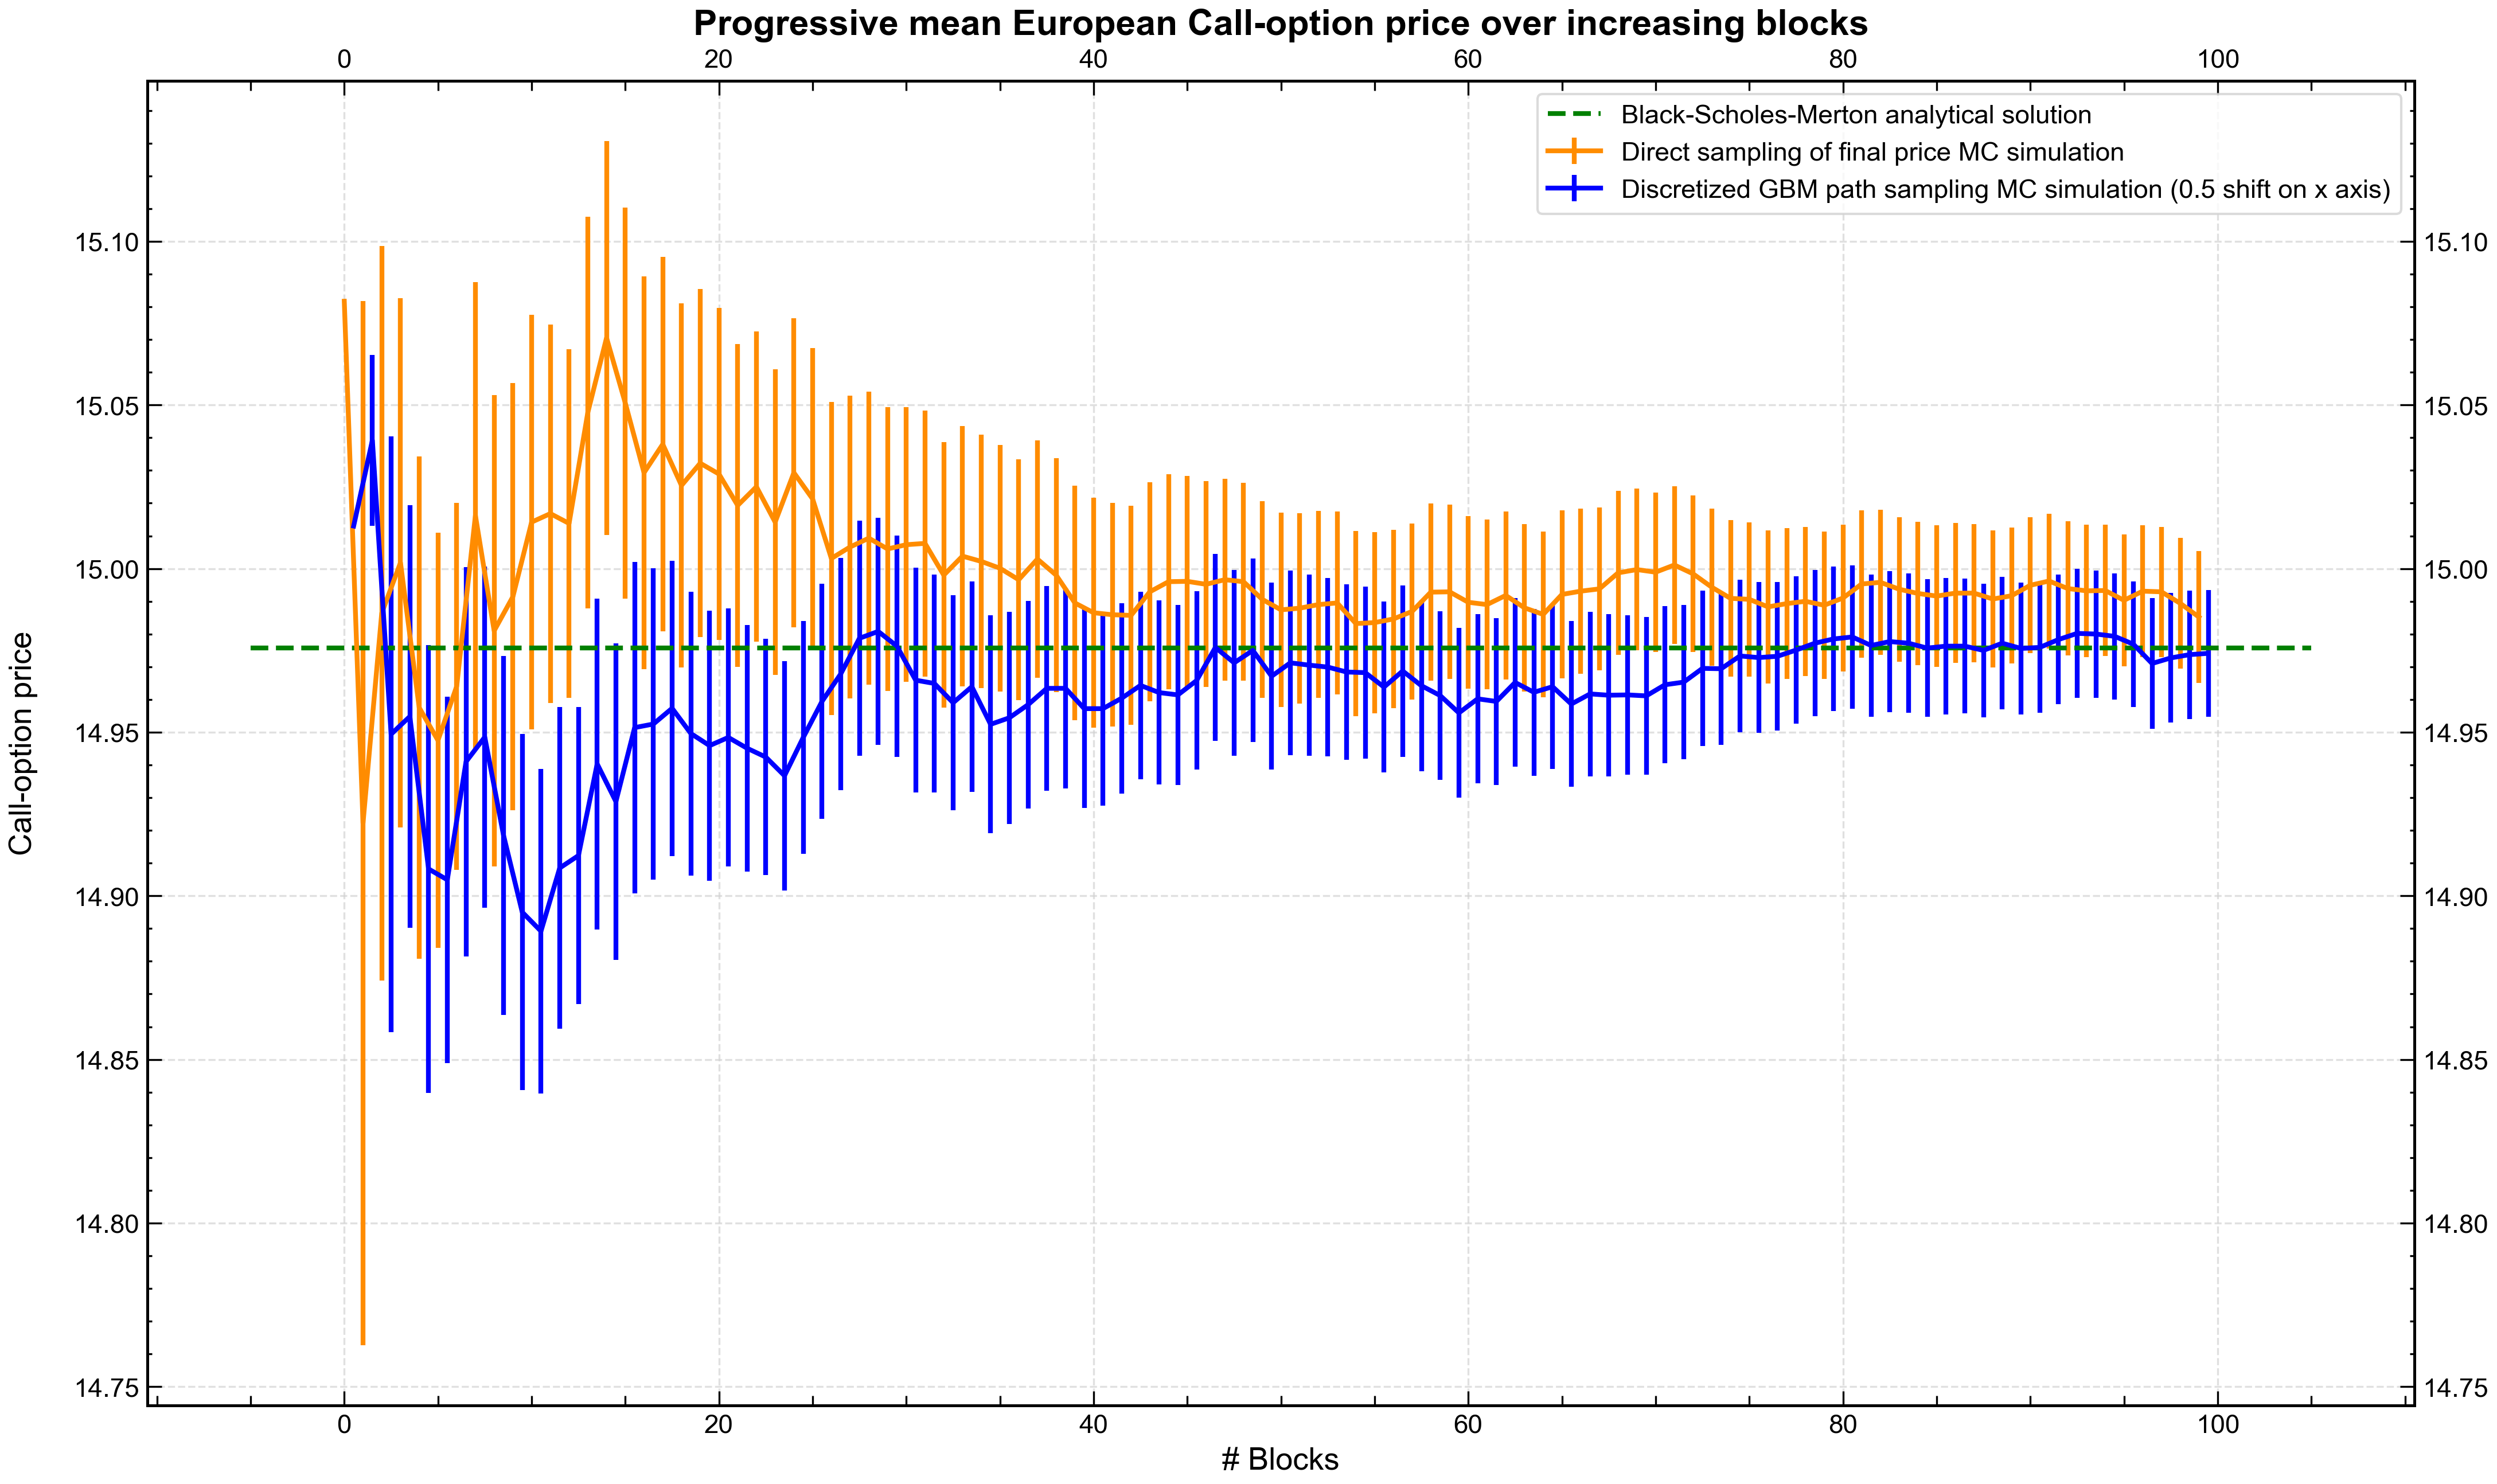

Black-Scholes-Merton Call-option price :  14.975790778311286

Direct sampling MC simulation Call-option price :  14.985 ± 0.020
distance from true value in sigma unit :  0.47 sigma

Discretized sampling MC simulation Call-option price :  14.974 ± 0.019
distance from true value in sigma unit :  0.09 sigma

t-ratio : 0.40


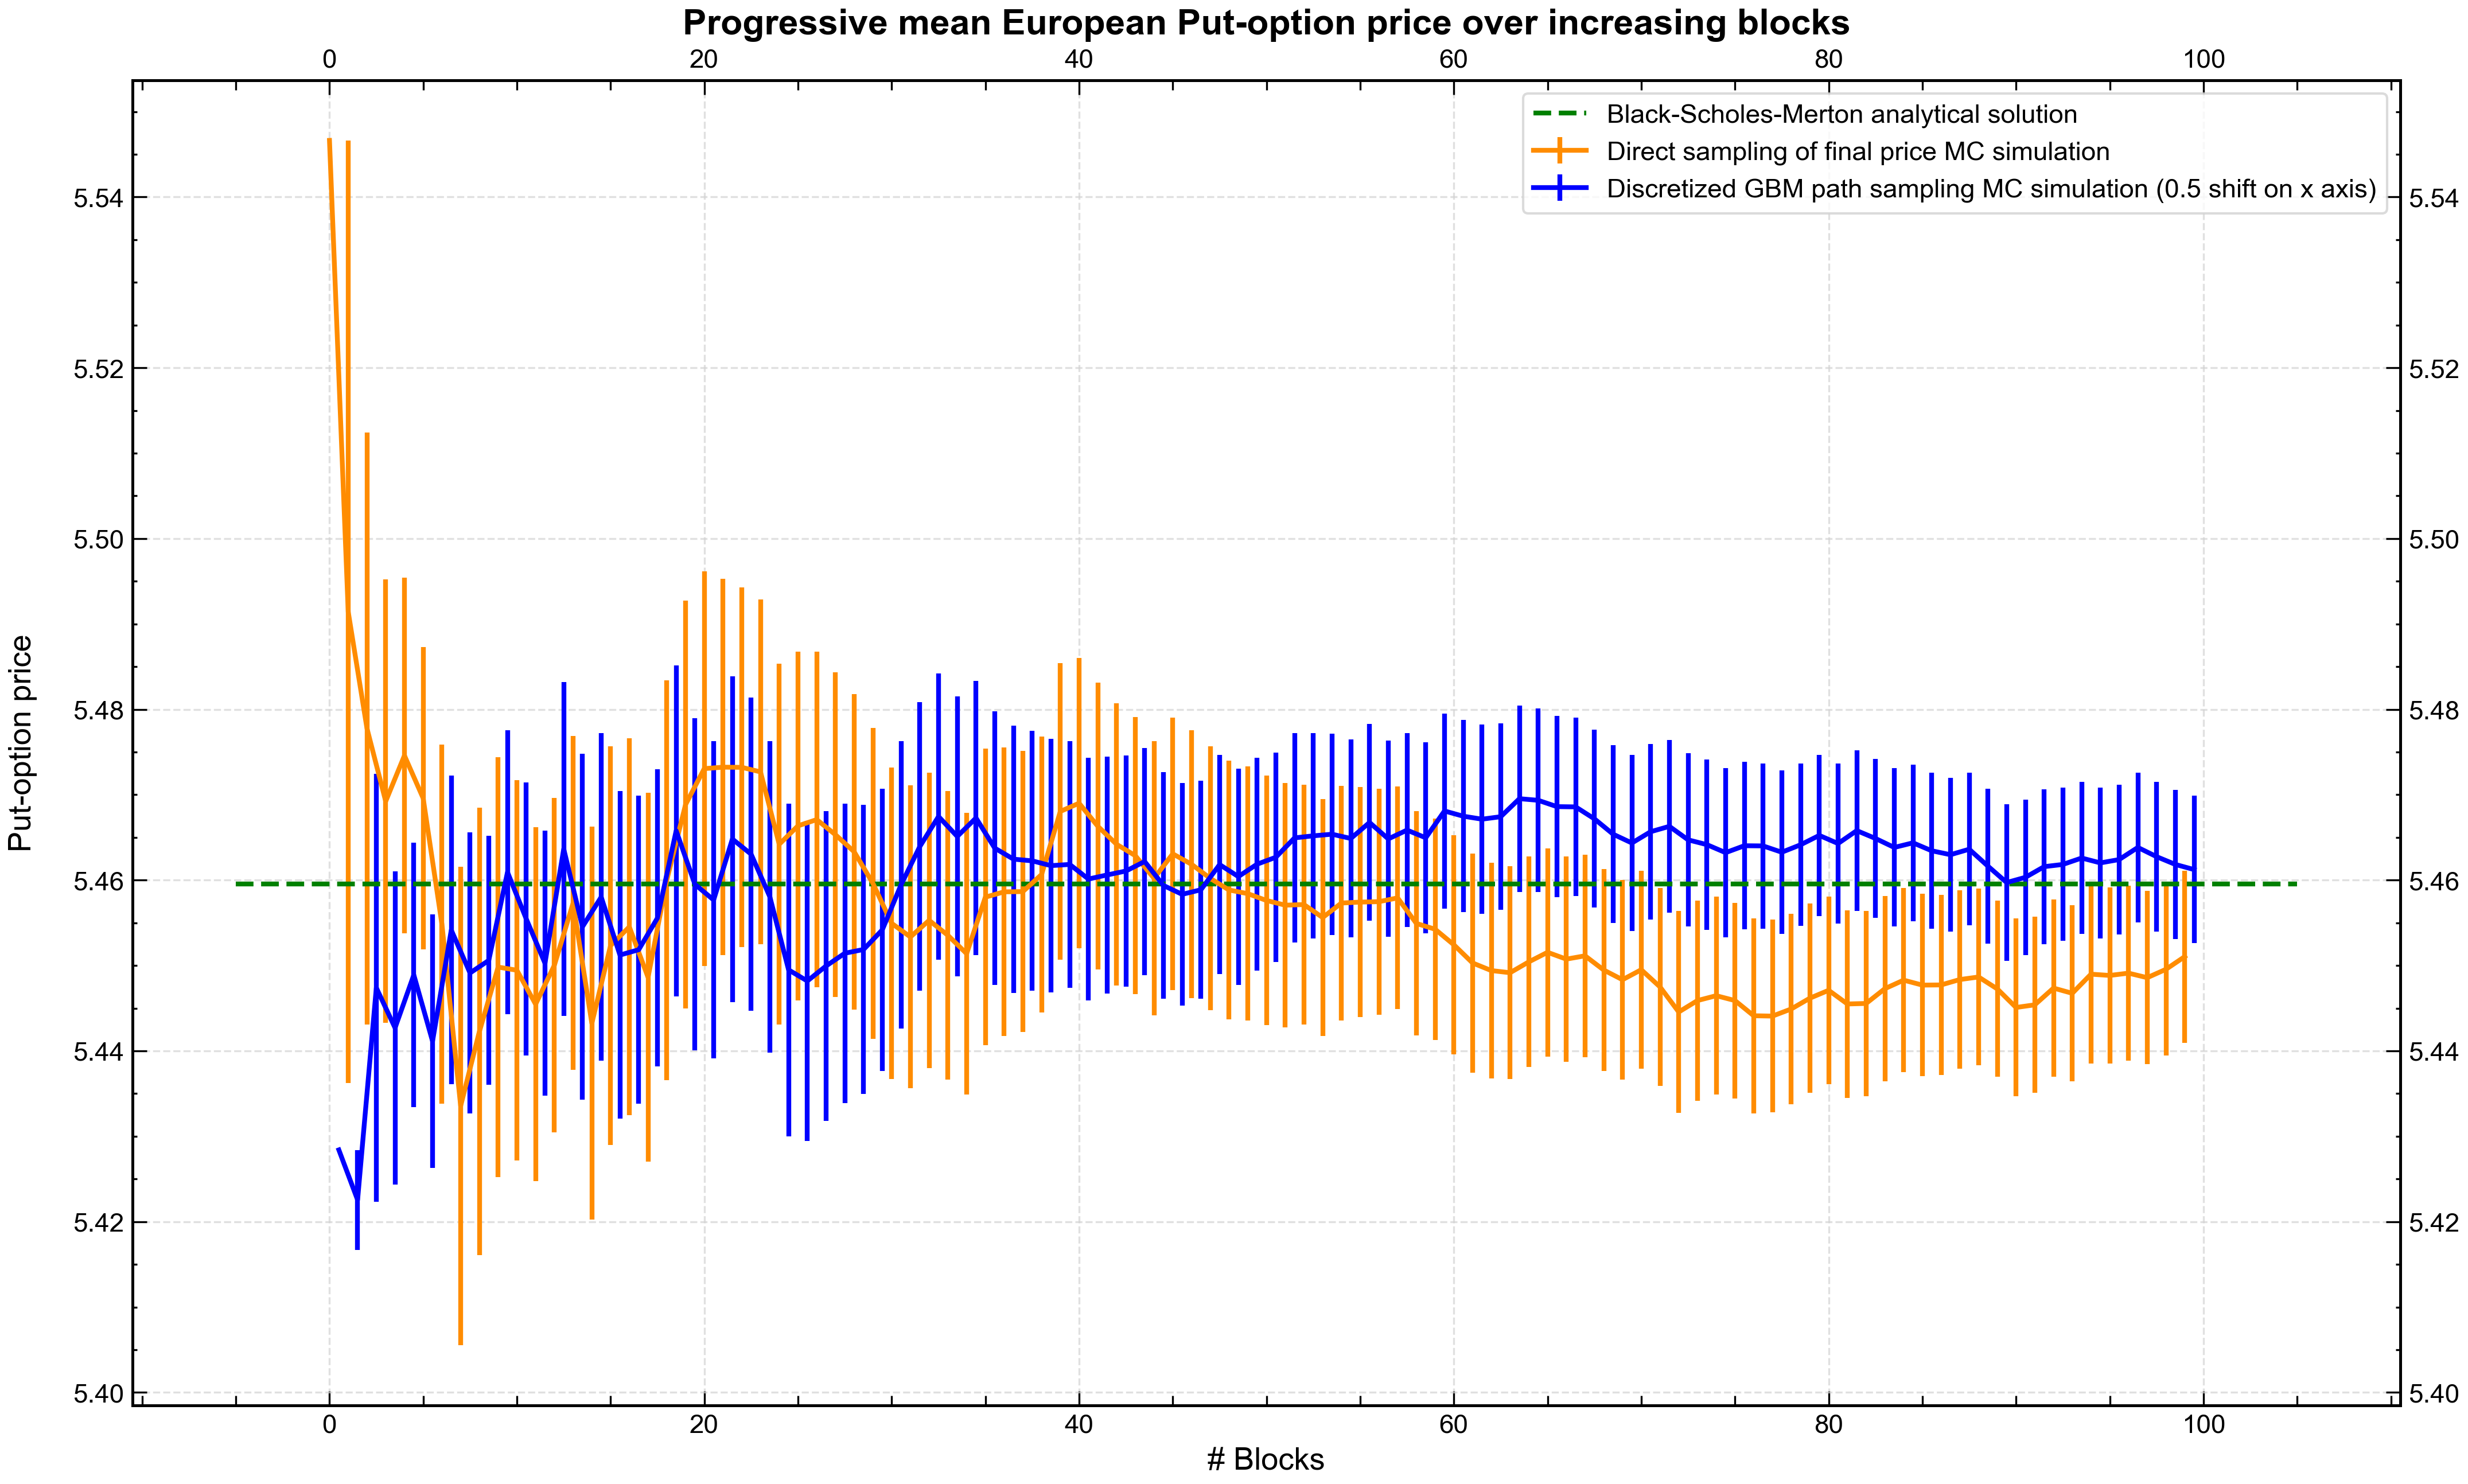

Black-Scholes-Merton Put-option price :  5.4595325819072364

Direct sampling MC simulation Put-option price :  5.451 ± 0.010
distance from true value in sigma unit :  0.84 sigma

Discretized sampling MC simulation Put-option price :  5.461 ± 0.009
distance from true value in sigma unit :  0.20 sigma

t-ratio : 0.77


In [3]:
title = ["Progressive mean European Call-option price over increasing blocks", "Progressive mean European Put-option price over increasing blocks"]
file_path = "es_3/OUTPUT/"
file_name = ["call.data", "call2.data", "put.data", "put2.data"]
BS_solution = [call_price, put_price]
y_label = ["Call-option price", "Put-option price"]
n_blocks = 100

for i in range(2) :

    x, mean, error = np.loadtxt(file_path + file_name[2*i], usecols=(0,2,3), unpack = 'true')
    mean2, error2 = np.loadtxt(file_path + file_name[2*i+1], usecols=(2,3), unpack = 'true')

    # plotting progressive mean values for simulation with 10^5 and 10^7 total throws
    fig = plt.figure(figsize = (17,10))
    plt.title(title[i])
    plt.errorbar(x, mean, yerr = error, color = "darkorange", label = "Direct sampling of final price MC simulation")
    # 0.5 shift on x axis to avoid plot superpositions
    plt.errorbar(x + 0.5, mean2, yerr = error2, color = "blue", label = "Discretized GBM path sampling MC simulation (0.5 shift on x axis)")
    plt.hlines(BS_solution[i], -5, n_blocks + 5, linestyle = "--", color = "green", label = "Black-Scholes-Merton analytical solution")
    plt.xlabel('# Blocks')
    plt.ylabel(y_label[i], labelpad=15)
    # plt.grid(True, ls='--')
    plt.legend()

    plt.show()
    if i == 0:
        fig.savefig("es_3/plot/call_option_sampling.png")
    else:
        fig.savefig("es_3/plot/put_option_sampling.png")


    # printing output values
    if i == 0 :
        print("Black-Scholes-Merton Call-option price : ", BS_solution[i])
        print("\nDirect sampling MC simulation Call-option price : ", round(mean[-1],3), "±", "{:.3f}".format(round(error[-1],5)))
        print("distance from true value in sigma unit : ",round(abs(mean[-1] - BS_solution[i])/error[-1],2),"sigma")
        print("\nDiscretized sampling MC simulation Call-option price : ", round(mean2[-1],3), "±", "{:.3f}".format(round(error2[-1],5)))
        print("distance from true value in sigma unit : ",round(abs(mean2[-1] - BS_solution[i])/error2[-1],2),"sigma")
        print("\nt-ratio :", "{:.2f}".format((abs(mean[-1]-mean2[-1])/np.sqrt(error[-1]*error[-1] + error2[-1]*error2[-1]))))
    else :
        print("Black-Scholes-Merton Put-option price : ", BS_solution[i])
        print("\nDirect sampling MC simulation Put-option price : ", round(mean[-1],3), "±", "{:.3f}".format(round(error[-1],5)))
        print("distance from true value in sigma unit : ",round(abs(mean[-1] - BS_solution[i])/error[-1],2),"sigma")
        print("\nDiscretized sampling MC simulation Put-option price : ", round(mean2[-1],3), "±", "{:.3f}".format(round(error2[-1],5)))
        print("distance from true value in sigma unit : ","{:.2f}".format(round(abs(mean2[-1] - BS_solution[i])/error2[-1], 3)),"sigma")
        print("\nt-ratio :", "{:.2f}".format((abs(mean[-1]-mean2[-1])/np.sqrt(error[-1]*error[-1] + error2[-1]*error2[-1]))))


<h4>Conclusions</h4>

**Call-option price simulation**

Monte Carlo simulation through direct sampling produces an estimation of call-option price equal to: 

$$\langle C[S(0),0]\rangle_{\text{DIR}} = 14.985 \pm 0.020,$$

with a **Z-score** from the analytical value given by the **lack-Scholes-Merton model** equal to $0.47\sigma$.

Monte Carlo simulation through direct sampling produces an estimation of call-option price equal to: 

$$\langle C[S(0),0]\rangle_{\text{DISC}} = 14.974 \pm 0.019,$$

with a **Z-score** from the analytical value given by the **lack-Scholes-Merton model** equal to $0.09\sigma$.

<span style="color:green">Both simulations results demonstrate excellent agreement with the analytical BSM price. The Z-scores ($0.47 \sigma$ and $0.09 \sigma$) are well within the $2\sigma$ range, confirming that both estimations are **statistically consistent** with the expected analytical value.</span>

<span style="color:green">Furthermore, we assess the equivalence of the two sampling methods by calculating the **t-ratio** comparing the two means:</span>

$$t = \frac{\mid \langle C[S(0),0]\rangle_{\text{DIR}} - \langle C[S(0),0]\rangle_{\text{DISC}} \mid}{\sqrt{\sigma^2_{C,\text{DIR}} + \sigma^2_{C,\text{DISC}}}} = 0.39.$$

<span style="color:green">Since the calculated t-ratio of $0.39$ is significantly **less than** $2$, we conclude that the results from the direct and discretized simulations are **statistically equal**.</span>

**Put-option price simulation**

Monte Carlo simulation through direct sampling produces an estimation of call-option price equal to: 

$$\langle P[S(0),0]\rangle_{\text{DIR}} = 5.451 \pm 0.010,$$

with a **Z-score** from the analytical value given by the **lack-Scholes-Merton model** equal to $0.84\sigma$.

Monte Carlo simulation through direct sampling produces an estimation of call-option price equal to: 

$$\langle P[S(0),0]\rangle_{\text{DISC}} = 5.461 \pm 0.009,$$

with a **Z-score** from the analytical value given by the **lack-Scholes-Merton model** equal to $0.20\sigma$.

<span style="color:green">Similarly, the put option prices obtained via Monte Carlo simulations are **statistically consistent** with the analytical BSM price, as both **Z-scores** ($0.84 \sigma$ and $0.20 \sigma$) fall within the $2 \sigma$ confidence interval.</span>

<span style="color:green">The statistical equivalence between the two simulation methods is confirmed by the low **t-ratio**</span>

$$t = \frac{\mid \langle P[S(0),0]\rangle_{\text{DIR}} - \langle P[S(0),0]\rangle_{\text{DISC}} \mid}{\sqrt{\sigma^2_{P,\text{DIR}} + \sigma^2_{P,\text{DISC}}}} = 0.77.$$

<span style="color:green">Given that the t-ratio of 0.77 is **less than** $2$, the results from the direct and discretized methods are **statistically indistinguishable**.</span>

Looking up to the plots we can visually appreciate how, as the number of GBM samples increase, the uncertainties consistently descrease, as expected from the CLT.

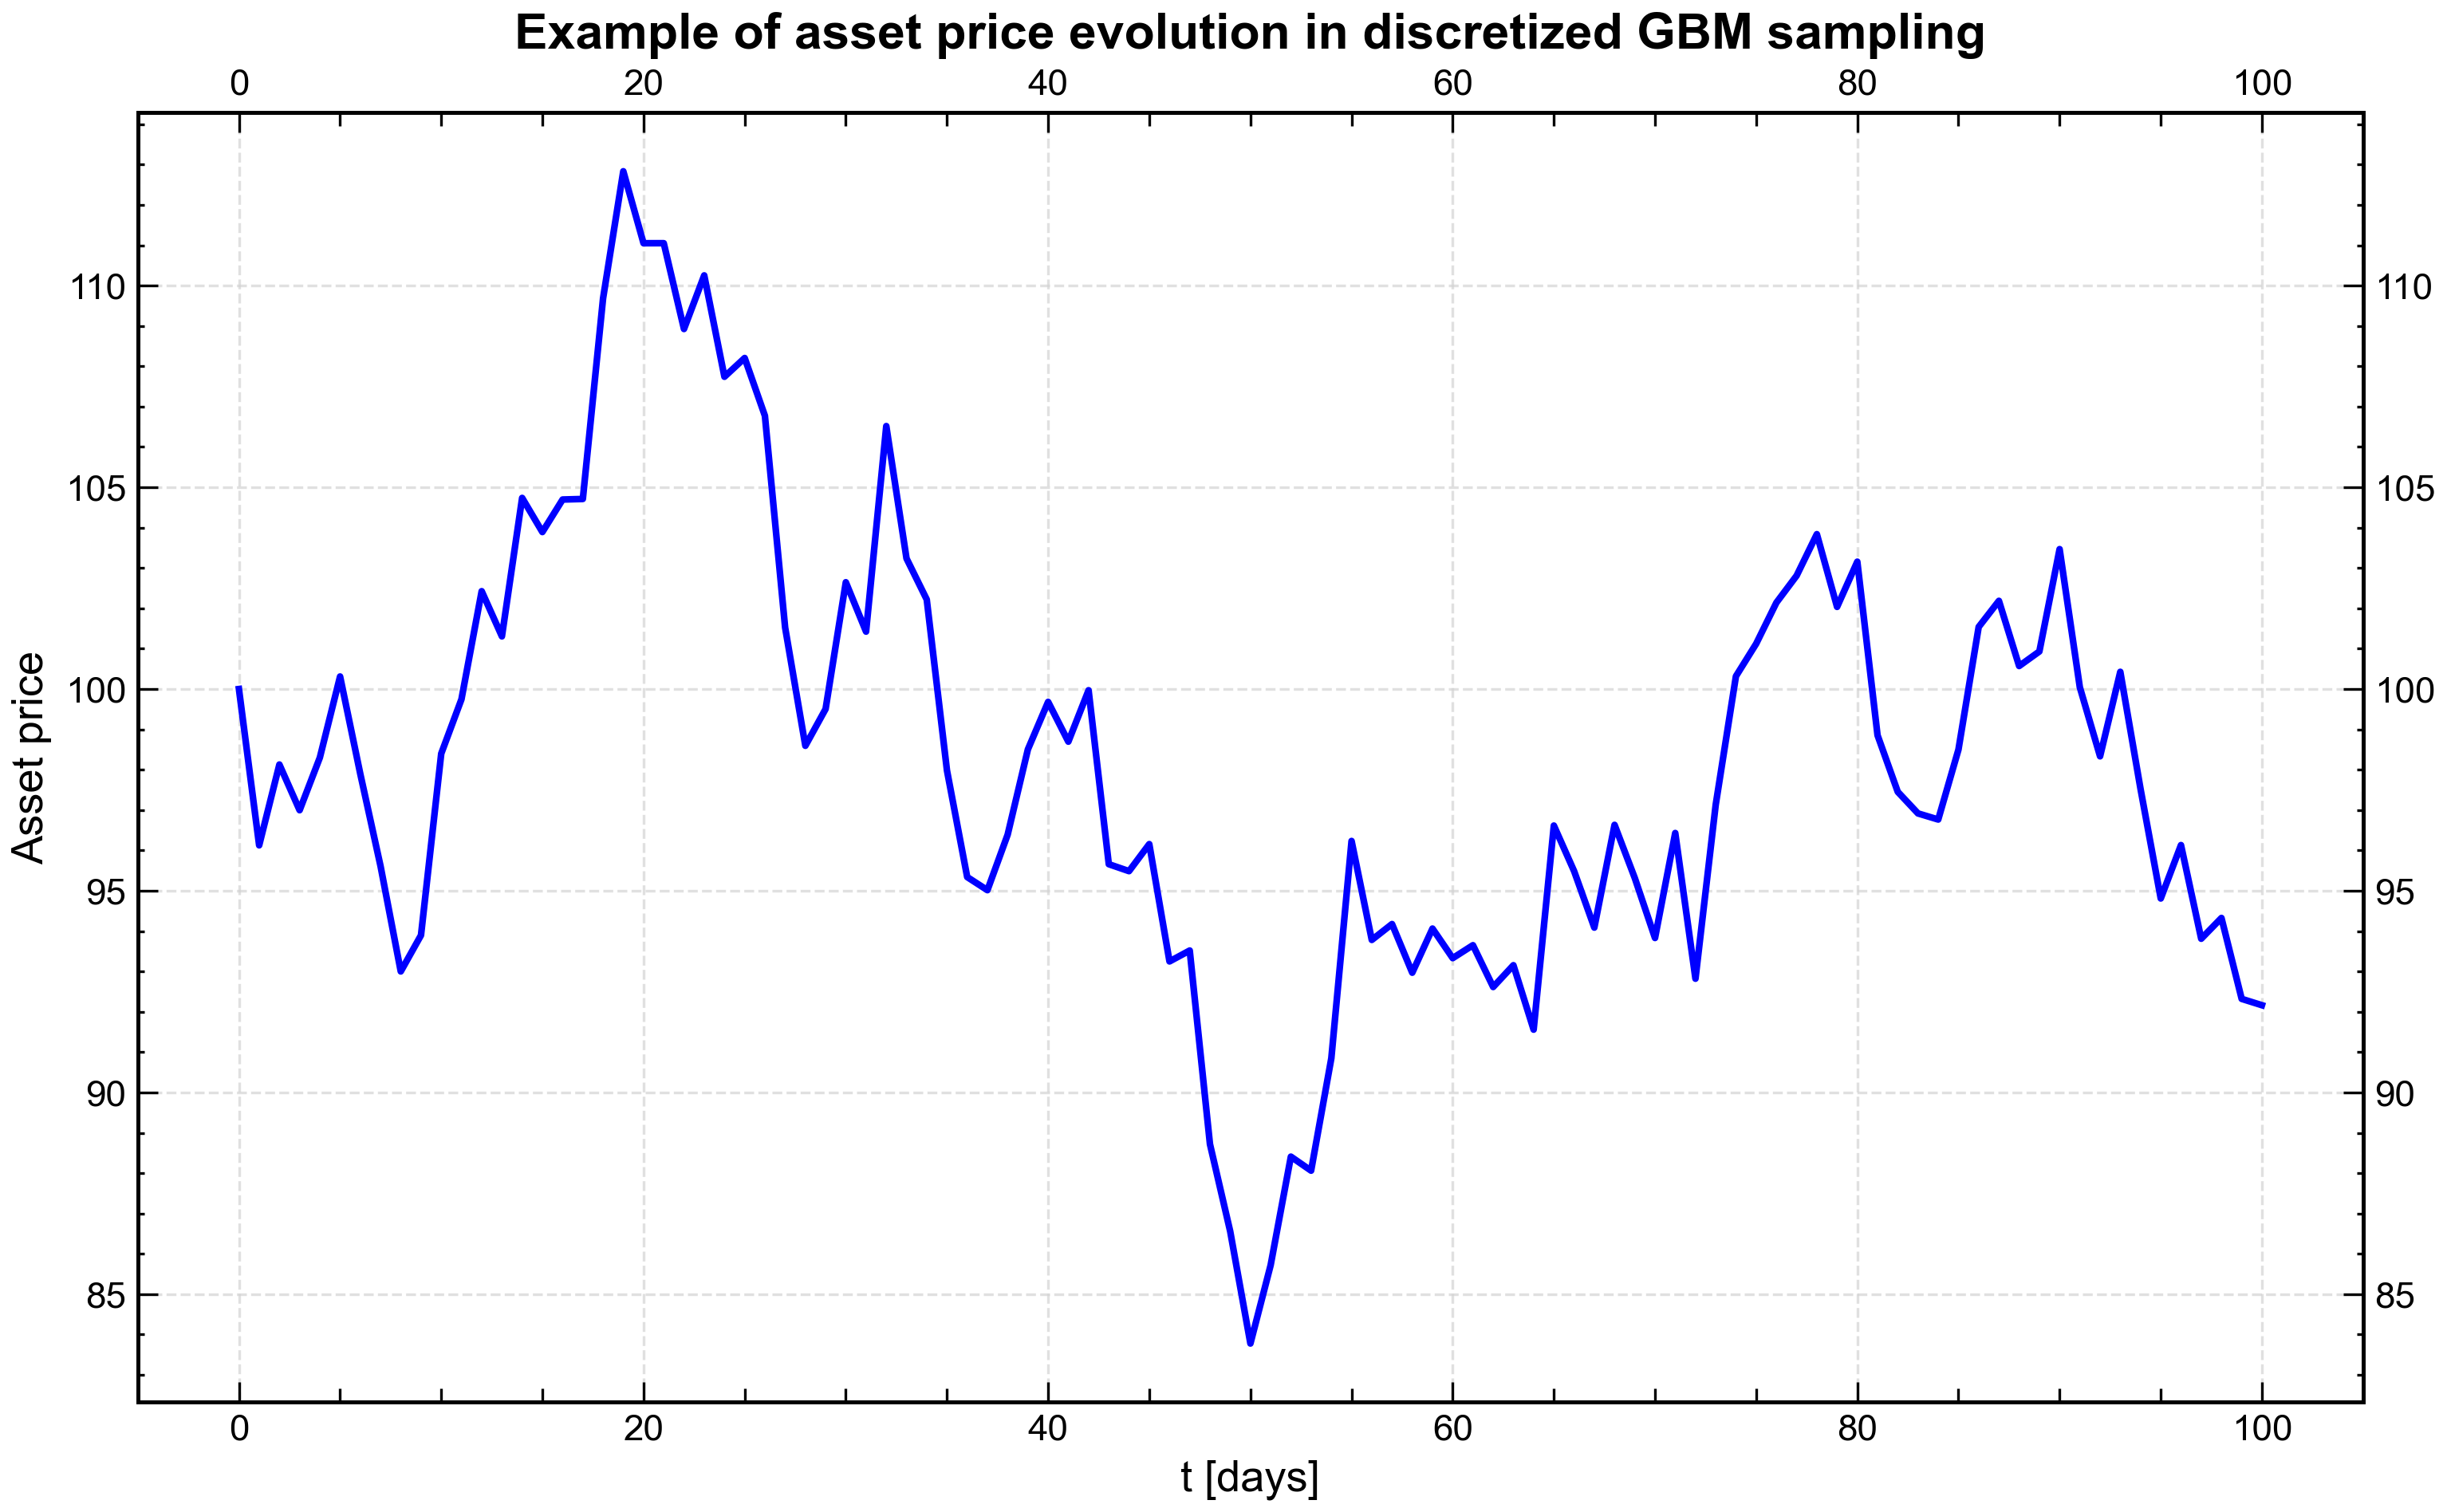

In [4]:
days, asset_evolution = np.loadtxt("es_3/OUTPUT/asset2.data", unpack = True)
days = np.insert(days, 100, 100)
asset_evolution = np.insert(asset_evolution, 0, 100.0)
fig = plt.figure(figsize = (12,7) )
plt.plot(days, asset_evolution, color= "blue")
plt.title("Example of asset price evolution in discretized GBM sampling")
plt.xlabel('t [days]')
plt.ylabel("Asset price")
# plt.grid(True, ls ="--")

plt.show()
fig.savefig("es_3/plot/asset_price_evolution.png")
